# Step 5 — Satellite Validation

**Goal:** Check whether flood articles detected by our classifier actually correspond to real flooding on the ground.

We do this by comparing two signals over time:
- **News signal** — weekly count of flood articles from our classifier
- **Satellite signal** — weekly flooded area (m²) measured by Sentinel-1 radar satellite

If both signals spike at the same time → our classifier is picking up real events, not noise.

We use the pre-classified `all_isFlood.json` (3,815 articles) which has dates and division labels — larger than our labeled set and ready to use.

## 0. Imports

In [38]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

# Display settings
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load the flood articles (news signal)

In [39]:
# Load pre-classified flood articles
# These 3,815 articles are all classified as flood=True by the IRI team
with open('data/classifier/timeseries_data/all_data/all_isFlood.json', 'r') as f:
    all_flood = json.load(f)

print(f'Total flood articles: {len(all_flood)}')

# Convert to DataFrame
flood_df = pd.DataFrame(all_flood)

# Parse the datePublished column — it comes in several formats
flood_df['date'] = pd.to_datetime(flood_df['datePublished'], utc=True, errors='coerce')
flood_df['date'] = flood_df['date'].dt.tz_localize(None)  # remove timezone for easier comparison

# Drop articles with no date
flood_df = flood_df[flood_df['date'].notna()].copy()
print(f'Articles with valid dates: {len(flood_df)}')
print(f'Date range: {flood_df["date"].min().date()} to {flood_df["date"].max().date()}')

Total flood articles: 3815
Articles with valid dates: 1667
Date range: 2007-10-16 to 2020-09-14


In [40]:
# Focus on 2017-2020 to match the satellite data range
flood_df = flood_df[(flood_df['date'].dt.year >= 2017) & (flood_df['date'].dt.year <= 2020)].copy()
print(f'Articles in 2017-2020: {len(flood_df)}')

# Add a week column for aggregation (round each date down to nearest Monday)
flood_df['week'] = flood_df['date'].dt.to_period('W').dt.start_time

print('\nSample rows:')
print(flood_df[['date', 'week', 'divisions', 'newspaper']].head())

Articles in 2017-2020: 1504

Sample rows:
                  date       week  \
0  2017-08-31 06:03:11 2017-08-28   
4  2019-09-30 13:44:33 2019-09-30   
43 2019-08-04 07:27:37 2019-07-29   
51 2018-09-13 19:48:55 2018-09-10   
66 2019-05-05 03:37:46 2019-04-29   

                                            divisions newspaper  
0                                            [khulna]  dailySun  
4                                          [rajshahi]  dailySun  
43  [rajshahi, sylhet, rangpur, chattogram, dhaka,...  dailySun  
51                                            [dhaka]  dailySun  
66                                [dhaka, chattogram]  dailySun  


## 2. Load the Sentinel satellite data

In [41]:
def load_sentinel(filepath):
    """
    Load a Sentinel-1 CSV file and return a clean DataFrame.
    Handles missing rows and parses dates.
    """
    df = pd.read_csv(filepath)
    df.columns = ['date', 'flooded_area_m2', 'fractional_flooded']
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df[df['date'].notna() & df['flooded_area_m2'].notna()].copy()
    df = df.sort_values('date').reset_index(drop=True)
    # Add week column to match news data
    df['week'] = df['date'].dt.to_period('W').dt.start_time
    return df

# Load Bangladesh country-level satellite data
sentinel_bd = load_sentinel('data/classifier/other_data/Sentinel1_ts/Bangladesh-fulldata-2017-2020.csv')
print(f'Sentinel Bangladesh: {len(sentinel_bd)} weekly observations')
print(f'Date range: {sentinel_bd["date"].min().date()} to {sentinel_bd["date"].max().date()}')
print(sentinel_bd.head())

Sentinel Bangladesh: 198 weekly observations
Date range: 2017-01-08 to 2020-10-18
                           date  flooded_area_m2  fractional_flooded  \
0 2017-01-08 00:00:00.000000000   1815157271.852               0.013   
1 2017-01-15 00:00:00.000000000   1818505720.796               0.013   
2 2017-01-22 00:00:00.000000001   2234891294.102               0.016   
3 2017-01-29 00:00:00.000000001   4062998019.734               0.029   
4 2017-02-05 00:00:00.000000002   4150825806.754               0.030   

        week  
0 2017-01-02  
1 2017-01-09  
2 2017-01-16  
3 2017-01-23  
4 2017-01-30  


## 3. Country-level comparison — News vs Satellite

In [42]:
# Aggregate news articles by week (country level)
news_weekly = flood_df.groupby('week').size().reset_index(name='article_count')

# Merge news counts with satellite data on week
merged = pd.merge(sentinel_bd[['week', 'fractional_flooded']], news_weekly, on='week', how='left')
merged['article_count'] = merged['article_count'].fillna(0)

print(f'Merged dataset: {len(merged)} weeks')
print(merged.head(10))

Merged dataset: 198 weeks
        week  fractional_flooded  article_count
0 2017-01-02               0.013          0.000
1 2017-01-09               0.013          0.000
2 2017-01-16               0.016          0.000
3 2017-01-23               0.029          0.000
4 2017-01-30               0.030          0.000
5 2017-02-06               0.027          2.000
6 2017-02-13               0.027          0.000
7 2017-02-20               0.016          2.000
8 2017-02-27               0.011          0.000
9 2017-03-06               0.009          2.000


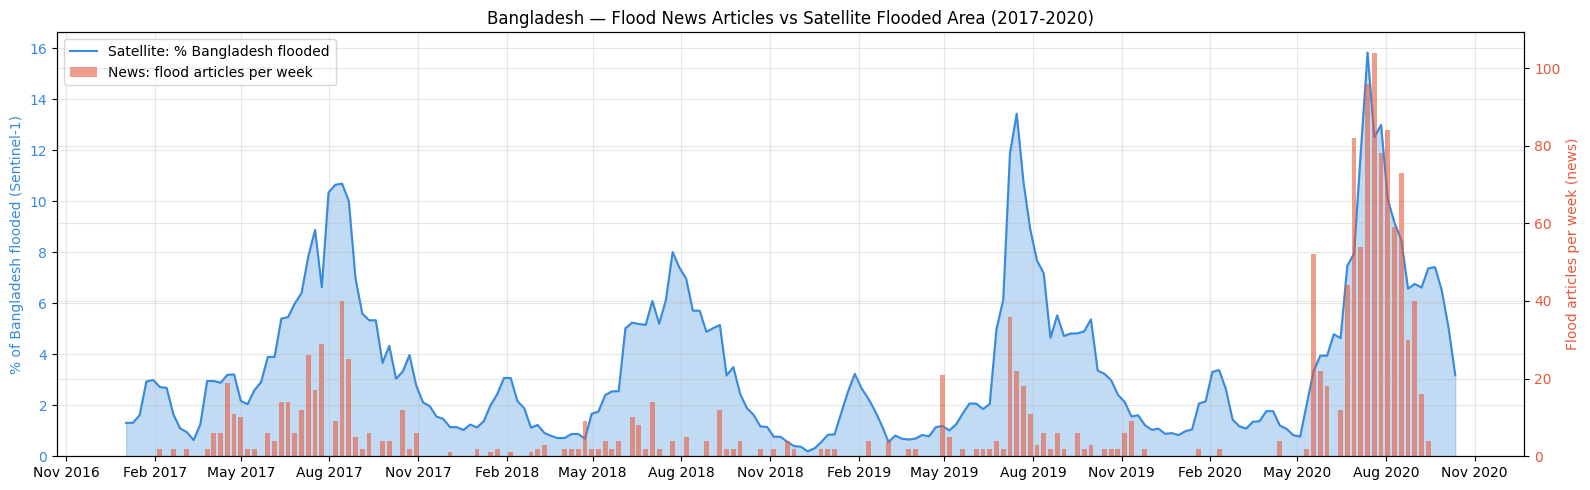

Saved: satellite_vs_news_bangladesh.png


In [43]:
# Plot both signals on the same chart with dual y-axes
fig, ax1 = plt.subplots(figsize=(16, 5))

# Satellite signal (left y-axis)
color_sat = '#378ADD'
ax1.fill_between(merged['week'], merged['fractional_flooded'] * 100,
                 alpha=0.3, color=color_sat)
ax1.plot(merged['week'], merged['fractional_flooded'] * 100,
         color=color_sat, linewidth=1.5, label='Satellite: % Bangladesh flooded')
ax1.set_ylabel('% of Bangladesh flooded (Sentinel-1)', color=color_sat)
ax1.tick_params(axis='y', labelcolor=color_sat)
ax1.set_ylim(0)

# News signal (right y-axis)
ax2 = ax1.twinx()
color_news = '#E8593C'
ax2.bar(merged['week'], merged['article_count'],
        width=5, alpha=0.6, color=color_news, label='News: flood articles per week')
ax2.set_ylabel('Flood articles per week (news)', color=color_news)
ax2.tick_params(axis='y', labelcolor=color_news)

# Formatting
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Bangladesh — Flood News Articles vs Satellite Flooded Area (2017-2020)')
plt.tight_layout()
plt.savefig('satellite_vs_news_bangladesh.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: satellite_vs_news_bangladesh.png')

In [44]:
# Calculate Pearson correlation between the two signals
# Only use weeks where both signals have data
valid = merged[(merged['article_count'] > 0) & (merged['fractional_flooded'].notna())]

corr, pvalue = pearsonr(valid['fractional_flooded'], valid['article_count'])

print('=== Correlation: News Articles vs Satellite Flooded Area ===')
print(f'Pearson r:  {corr:.3f}')
print(f'P-value:    {pvalue:.4f}')
print()
if pvalue < 0.05:
    print('Result: Statistically significant correlation (p < 0.05)')
    if corr > 0.5:
        print('Interpretation: Strong positive correlation — news reporting tracks real flooding well')
    elif corr > 0.3:
        print('Interpretation: Moderate correlation — news partially tracks real flooding')
    else:
        print('Interpretation: Weak correlation — news may not reflect actual flood severity')
else:
    print('Result: No statistically significant correlation found')

=== Correlation: News Articles vs Satellite Flooded Area ===
Pearson r:  0.693
P-value:    0.0000

Result: Statistically significant correlation (p < 0.05)
Interpretation: Strong positive correlation — news reporting tracks real flooding well


## 4. Division-level comparison

Now we break it down by division — does news reporting track satellite flooding equally across all regions of Bangladesh, or are some divisions under-reported?

In [45]:
# Divisions to analyze (must match both satellite files and division labels in news data)
divisions = {
    'dhaka':      'Dhaka',
    'sylhet':     'Sylhet',
    'rangpur':    'Rangpur',
    'rajshahi':   'Rajshahi',
    'chattogram': 'Chattogram',
    'khulna':     'Khulna',
    'barishal':   'Barishal',
    'mymensingh': 'Mymensingh'
}

# Explode divisions column so each article-division pair is one row
flood_exploded = flood_df.explode('divisions').copy()
flood_exploded['divisions'] = flood_exploded['divisions'].str.lower().str.strip()

# Store results for each division
division_results = []

for div_key, div_name in divisions.items():
    # Load satellite data for this division
    sentinel_div = load_sentinel(
        f'data/classifier/other_data/Sentinel1_ts/{div_name}-fulldata-2017-2020.csv'
    )
    
    # Filter news articles mentioning this division
    news_div = flood_exploded[flood_exploded['divisions'] == div_key]
    news_div_weekly = news_div.groupby('week').size().reset_index(name='article_count')
    
    # Merge
    merged_div = pd.merge(
        sentinel_div[['week', 'fractional_flooded']],
        news_div_weekly,
        on='week', how='left'
    )
    merged_div['article_count'] = merged_div['article_count'].fillna(0)
    
    # Correlation
    valid_div = merged_div[
        (merged_div['article_count'] > 0) & 
        (merged_div['fractional_flooded'].notna())
    ]
    
    if len(valid_div) > 10:
        corr, pval = pearsonr(valid_div['fractional_flooded'], valid_div['article_count'])
    else:
        corr, pval = np.nan, np.nan
    
    division_results.append({
        'Division': div_name,
        'News articles (2017-2020)': len(news_div),
        'Avg weekly flooded area (%)': merged_div['fractional_flooded'].mean() * 100,
        'Peak flooded area (%)': merged_div['fractional_flooded'].max() * 100,
        'Pearson r (news vs satellite)': corr,
        'P-value': pval,
        '_merged': merged_div  # store for plotting
    })
    
    print(f'{div_name}: {len(news_div)} articles | r = {corr:.3f} | p = {pval:.3f}')

print('\nDone!')

Dhaka: 718 articles | r = 0.724 | p = 0.000
Sylhet: 438 articles | r = 0.502 | p = 0.000
Rangpur: 675 articles | r = 0.709 | p = 0.000
Rajshahi: 602 articles | r = 0.639 | p = 0.000
Chattogram: 316 articles | r = 0.579 | p = 0.000
Khulna: 235 articles | r = 0.141 | p = 0.373
Barishal: 187 articles | r = 0.099 | p = 0.539
Mymensingh: 450 articles | r = 0.669 | p = 0.000

Done!


In [46]:
# Summary table
summary_cols = ['Division', 'News articles (2017-2020)', 
                'Avg weekly flooded area (%)', 'Peak flooded area (%)',
                'Pearson r (news vs satellite)', 'P-value']
results_df = pd.DataFrame(division_results)[summary_cols]
results_df = results_df.sort_values('Pearson r (news vs satellite)', ascending=False)

print('=== Division-level: News vs Satellite Correlation ===')
print(results_df.to_string(index=False))

=== Division-level: News vs Satellite Correlation ===
  Division  News articles (2017-2020)  Avg weekly flooded area (%)  Peak flooded area (%)  Pearson r (news vs satellite)  P-value
     Dhaka                        718                        4.330                 19.649                          0.724    0.000
   Rangpur                        675                        2.783                 17.783                          0.709    0.000
Mymensingh                        450                        5.147                 28.555                          0.669    0.000
  Rajshahi                        602                        4.728                 22.820                          0.639    0.000
Chattogram                        316                        1.293                  5.917                          0.579    0.000
    Sylhet                        438                        9.268                 33.005                          0.502    0.000
    Khulna                        23

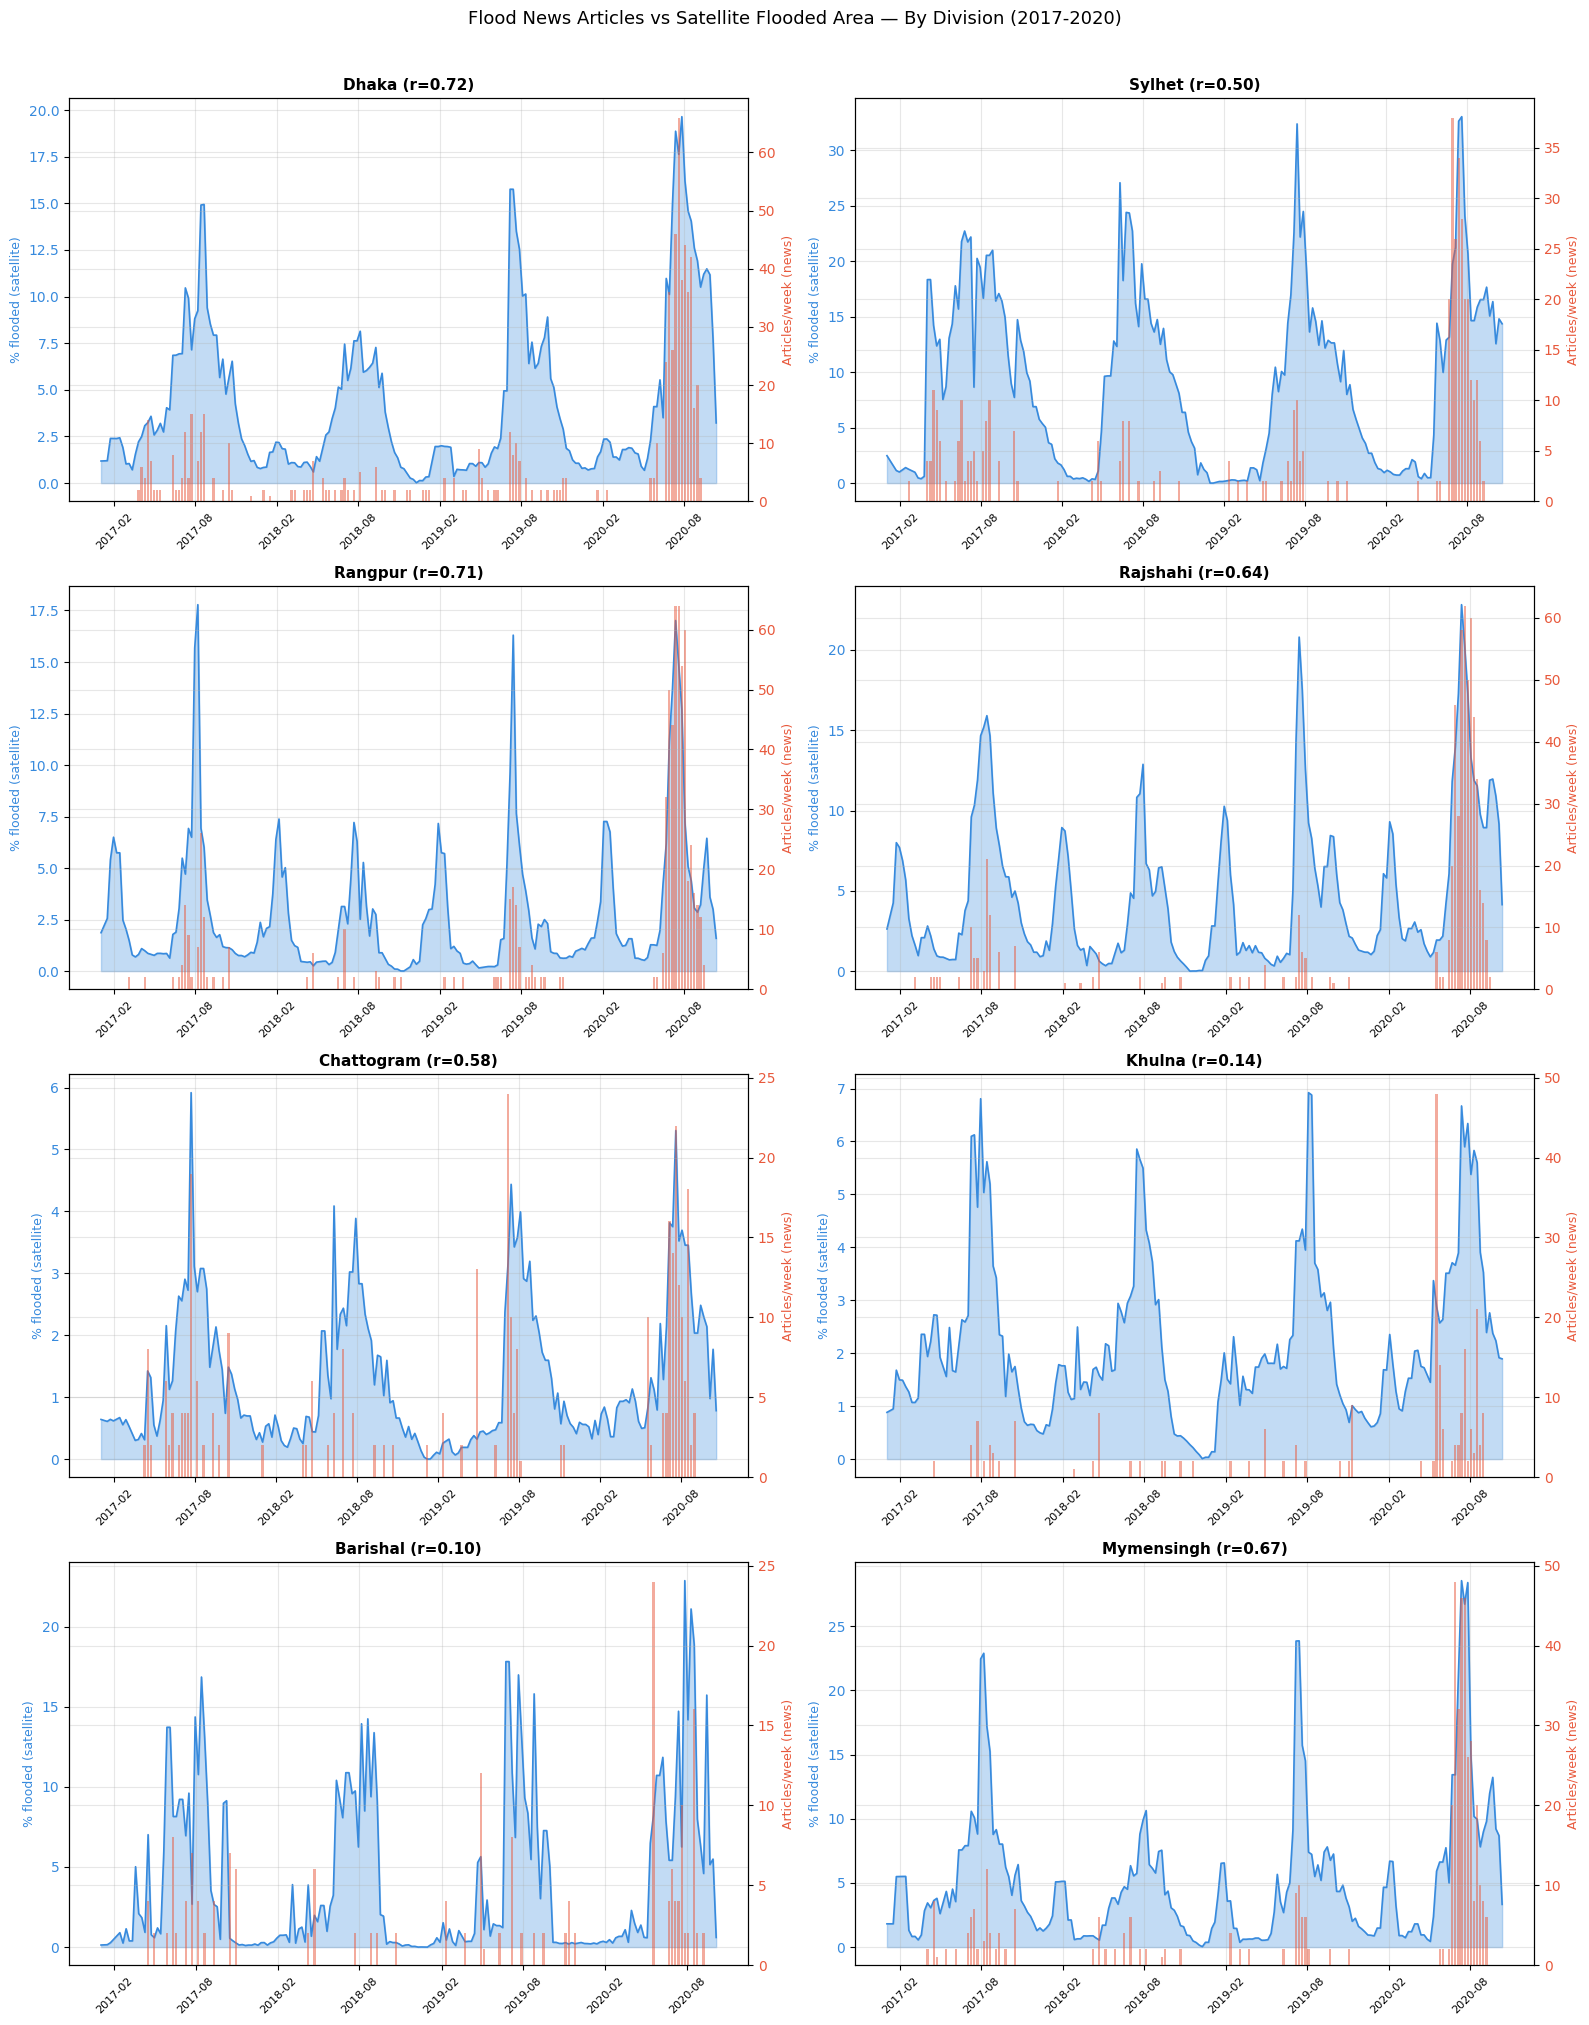

Saved: satellite_vs_news_divisions.png


In [47]:
# Plot all 8 divisions in a grid
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, row in enumerate(division_results):
    ax1 = axes[i]
    merged_div = row['_merged']
    div_name = row['Division']
    corr = row['Pearson r (news vs satellite)']

    # Satellite
    ax1.fill_between(merged_div['week'], merged_div['fractional_flooded'] * 100,
                     alpha=0.3, color='#378ADD')
    ax1.plot(merged_div['week'], merged_div['fractional_flooded'] * 100,
             color='#378ADD', linewidth=1.2)
    ax1.set_ylabel('% flooded (satellite)', color='#378ADD', fontsize=9)
    ax1.tick_params(axis='y', labelcolor='#378ADD')

    # News
    ax2 = ax1.twinx()
    ax2.bar(merged_div['week'], merged_div['article_count'],
            width=5, alpha=0.5, color='#E8593C')
    ax2.set_ylabel('Articles/week (news)', color='#E8593C', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='#E8593C')

    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, fontsize=8)

    r_str = f'r={corr:.2f}' if not np.isnan(corr) else 'r=N/A'
    ax1.set_title(f'{div_name} ({r_str})', fontsize=11, fontweight='bold')

plt.suptitle('Flood News Articles vs Satellite Flooded Area — By Division (2017-2020)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('satellite_vs_news_divisions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: satellite_vs_news_divisions.png')

## 5. Which divisions are under-reported?

High satellite flooding + low news coverage = under-reported region.
This is one of the most important policy findings.

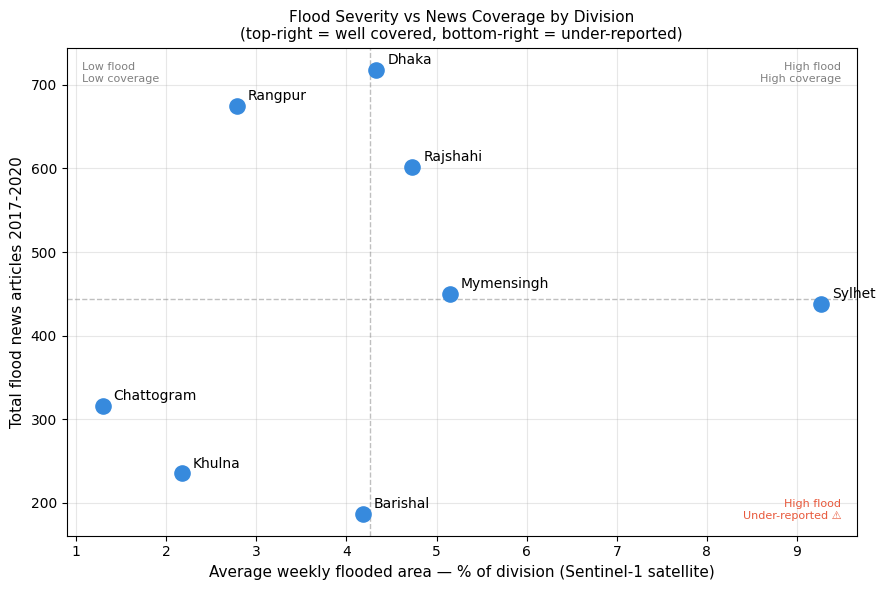

Saved: underreported_divisions.png


In [48]:
# Scatter plot: avg satellite flooded area vs total news articles per division
fig, ax = plt.subplots(figsize=(9, 6))

for row in division_results:
    x = row['Avg weekly flooded area (%)']
    y = row['News articles (2017-2020)']
    ax.scatter(x, y, s=120, color='#378ADD', zorder=3)
    ax.annotate(
        row['Division'],
        (x, y),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=10
    )

ax.set_xlabel('Average weekly flooded area — % of division (Sentinel-1 satellite)', fontsize=11)
ax.set_ylabel('Total flood news articles 2017-2020', fontsize=11)
ax.set_title('Flood Severity vs News Coverage by Division\n(top-right = well covered, bottom-right = under-reported)', fontsize=11)
ax.grid(True, alpha=0.3)

# Add quadrant lines at medians
med_x = np.median([r['Avg weekly flooded area (%)'] for r in division_results])
med_y = np.median([r['News articles (2017-2020)'] for r in division_results])
ax.axvline(med_x, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(med_y, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Label quadrants
ax.text(0.02, 0.97, 'Low flood\nLow coverage', transform=ax.transAxes,
        fontsize=8, color='gray', va='top')
ax.text(0.98, 0.97, 'High flood\nHigh coverage', transform=ax.transAxes,
        fontsize=8, color='gray', va='top', ha='right')
ax.text(0.98, 0.03, 'High flood\nUnder-reported ⚠', transform=ax.transAxes,
        fontsize=8, color='#E8593C', va='bottom', ha='right')

plt.tight_layout()
plt.savefig('underreported_divisions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: underreported_divisions.png')

## 6. Key findings summary

In [49]:
print('=== STEP 5 KEY FINDINGS ===')
print()

# Best and worst correlated divisions
sorted_results = sorted(division_results, key=lambda x: x['Pearson r (news vs satellite)'] 
                        if not np.isnan(x['Pearson r (news vs satellite)']) else -999, reverse=True)

print('Best correlated division (news tracks satellite most closely):')
best = sorted_results[0]
print(f"  {best['Division']} — r = {best['Pearson r (news vs satellite)']:.3f}")

print()
print('Worst correlated division (news least reflects actual flooding):')
worst = sorted_results[-1]
print(f"  {worst['Division']} — r = {worst['Pearson r (news vs satellite)']:.3f}")

print()
# Most under-reported
most_flooded = max(division_results, key=lambda x: x['Avg weekly flooded area (%)'])
least_covered = min(division_results, key=lambda x: x['News articles (2017-2020)'])
print(f"Most flooded division by satellite: {most_flooded['Division']} ({most_flooded['Avg weekly flooded area (%)']:.2f}% avg)")
print(f"Least news-covered division: {least_covered['Division']} ({least_covered['News articles (2017-2020)']} articles)")

print()
print('Plots saved:')
print('  satellite_vs_news_bangladesh.png — country-level time series')
print('  satellite_vs_news_divisions.png  — division-level grid')
print('  underreported_divisions.png      — scatter: severity vs coverage')

=== STEP 5 KEY FINDINGS ===

Best correlated division (news tracks satellite most closely):
  Dhaka — r = 0.724

Worst correlated division (news least reflects actual flooding):
  Barishal — r = 0.099

Most flooded division by satellite: Sylhet (9.27% avg)
Least news-covered division: Barishal (187 articles)

Plots saved:
  satellite_vs_news_bangladesh.png — country-level time series
  satellite_vs_news_divisions.png  — division-level grid
  underreported_divisions.png      — scatter: severity vs coverage
